In [133]:
# Import libraries
import pandas as p
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error
from skimage.io import imread
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

In [75]:
# Read data
data0 = pd.read_csv("../models/multiclass_10K_b0/test/test_predictions_1.csv")
data1 = pd.read_csv("../models/multiclass_10K_b1/test/test_predictions_3.csv")
data2 = pd.read_csv("../models/multiclass_10K_b2/test/test_predictions_0.csv")
data3 = pd.read_csv("../models/multiclass_10K_b3/test/test_predictions_0.csv")
data4 = pd.read_csv("../models/multiclass_10K_b4/test/test_predictions_1.csv")
data5 = pd.read_csv("../models/multiclass_10K_b5/test/test_predictions_0.csv")
data6 = pd.read_csv("../models/multiclass_10K_b6/test/test_predictions_4.csv")
data7 = pd.read_csv("../models/multiclass_10K_b7/test/test_predictions_4.csv")

data0["label"] = data0["target"].apply(lambda x: 1 if x > 0 else 0)
data1["label"] = data1["target"].apply(lambda x: 1 if x > 0 else 0)
data2["label"] = data2["target"].apply(lambda x: 1 if x > 0 else 0)
data3["label"] = data3["target"].apply(lambda x: 1 if x > 0 else 0)
data4["label"] = data4["target"].apply(lambda x: 1 if x > 0 else 0)
data5["label"] = data5["target"].apply(lambda x: 1 if x > 0 else 0)
data6["label"] = data6["target"].apply(lambda x: 1 if x > 0 else 0)
data7["label"] = data7["target"].apply(lambda x: 1 if x > 0 else 0)

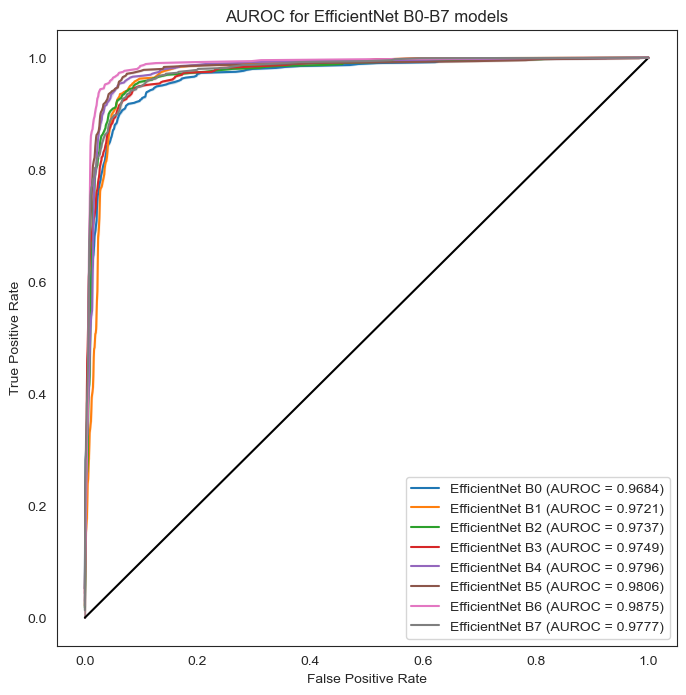

In [153]:
rocauc0 = roc_auc_score(data0["label"], data0["scores"])
rocauc1 = roc_auc_score(data1["label"], data1["scores"])
rocauc2 = roc_auc_score(data2["label"], data2["scores"])
rocauc3 = roc_auc_score(data3["label"], data3["scores"])
rocauc4 = roc_auc_score(data4["label"], data4["scores"])
rocauc5 = roc_auc_score(data5["label"], data5["scores"])
rocauc6 = roc_auc_score(data6["label"], data6["scores"])
rocauc7 = roc_auc_score(data7["label"], data7["scores"])

sns.set_style("white")
fpr0, tpr0, thresholds0 = roc_curve(data0["label"], data0["scores"])
fpr1, tpr1, thresholds1 = roc_curve(data1["label"], data1["scores"])
fpr2, tpr2, thresholds2 = roc_curve(data2["label"], data2["scores"])
fpr3, tpr3, thresholds3 = roc_curve(data3["label"], data3["scores"])
fpr4, tpr4, thresholds4 = roc_curve(data4["label"], data4["scores"])
fpr5, tpr5, thresholds5 = roc_curve(data5["label"], data5["scores"])
fpr6, tpr6, thresholds6 = roc_curve(data6["label"], data6["scores"])
fpr7, tpr7, thresholds7 = roc_curve(data7["label"], data7["scores"])

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.plot([0, 1], [0, 1], 'k-')
# ax.plot(fpr, tpr,   label=f"ROC curve (area = {rocauc:.4f})")
# ax.plot(fpr1, tpr1, label=f"ROC curve (area = {rocauc1:.4f})")
# ax.plot(fpr2, tpr2, label=f"ROC curve (area = {rocauc2:.4f})")
# ax.plot(fpr3, tpr3, label=f"ROC curve (area = {rocauc3:.4f})")
# ax.plot(fpr4, tpr4, label=f"ROC curve (area = {rocauc4:.4f})")

sns.lineplot(x=fpr0, y=tpr0, label=f"EfficientNet B0 (AUROC = {rocauc0:.4f})", ax=ax, palette="husl")
sns.lineplot(x=fpr1, y=tpr1, label=f"EfficientNet B1 (AUROC = {rocauc1:.4f})", ax=ax, palette="husl")
sns.lineplot(x=fpr2, y=tpr2, label=f"EfficientNet B2 (AUROC = {rocauc2:.4f})", ax=ax, palette="husl")
sns.lineplot(x=fpr3, y=tpr3, label=f"EfficientNet B3 (AUROC = {rocauc3:.4f})", ax=ax, palette="husl")
sns.lineplot(x=fpr4, y=tpr4, label=f"EfficientNet B4 (AUROC = {rocauc4:.4f})", ax=ax, palette="husl")
sns.lineplot(x=fpr5, y=tpr5, label=f"EfficientNet B5 (AUROC = {rocauc5:.4f})", ax=ax, palette="husl")
sns.lineplot(x=fpr6, y=tpr6, label=f"EfficientNet B6 (AUROC = {rocauc6:.4f})", ax=ax, palette="husl")
sns.lineplot(x=fpr7, y=tpr7, label=f"EfficientNet B7 (AUROC = {rocauc7:.4f})", ax=ax, palette="husl")

# cutoff = 15
# ax.hlines(tpr[cutoff], 0, 1, linestyles="--", colors="grey")
# ax.vlines(fpr[cutoff], 0, 1, linestyles="--", colors="grey")
# ax.plot(fpr[cutoff], tpr[cutoff], "ro")
# ax.text(fpr[cutoff]+0.05, tpr[cutoff]-0.05, f"({thresholds[cutoff]:.2f})")

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('AUROC for EfficientNet B0-B7 models')
ax.legend(loc="lower right")
fig.savefig("../figures/auroc_best_test.pdf", dpi=300)
fig.savefig("../figures/auroc_best_test.png", dpi=300)
fig.savefig("../figures/auroc_best_test.svg", dpi=300)

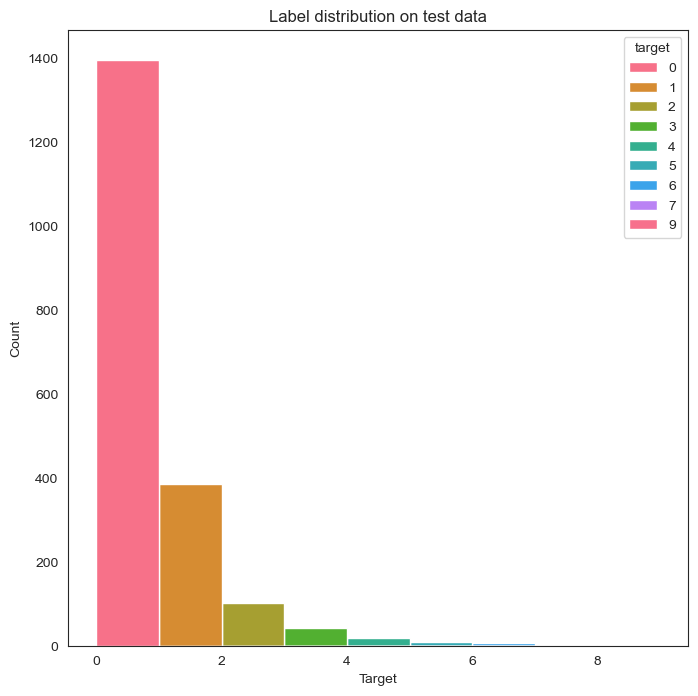

In [130]:
 # Plot distribution of target values
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.histplot(data= data0, x="target", binwidth=1, hue="target", palette="husl",  alpha=1, ax=ax)
ax.set_xlabel('Target')
ax.set_title('Label distribution on test data')
# ax.legend(loc="lower right")
fig.savefig("../figures/b0_test_distribution.pdf", dpi=300)
fig.savefig("../figures/b0_test_distribution.png", dpi=300)
fig.savefig("../figures/b0_test_distribution.svg", dpi=300)

# Read test data

In [47]:
results = pd.read_csv("../models/multiclass_10K/test/test_scores_0.csv")

,MAE,MSE,RMSE,ACC,ACC_balanced,f1_micro,f1_macro,f1_weighted,micronuclei,cells,micronuclei_cell_ratio,micronuclei_deviance
0,0.182785,0.239494,0.489381,0.841013,0.477691,0.841013,0.390235,0.843549,899,1975,0.45519,0.049683


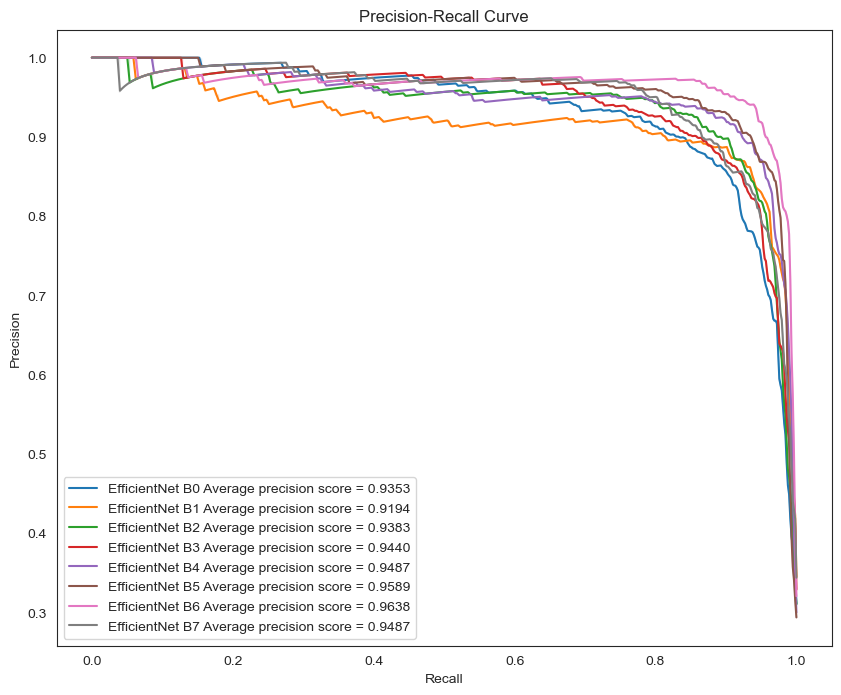

In [151]:

# Compute precision and recall values
precision0, recall0, _ = precision_recall_curve(data0["label"], data0["scores"])
precision1, recall1, _ = precision_recall_curve(data1["label"], data1["scores"])
precision2, recall2, _ = precision_recall_curve(data2["label"], data2["scores"])
precision3, recall3, _ = precision_recall_curve(data3["label"], data3["scores"])
precision4, recall4, _ = precision_recall_curve(data4["label"], data4["scores"])
precision5, recall5, _ = precision_recall_curve(data5["label"], data5["scores"])
precision6, recall6, _ = precision_recall_curve(data6["label"], data6["scores"])
precision7, recall7, _ = precision_recall_curve(data7["label"], data7["scores"])

# Calculate average precision
average_precision0 = average_precision_score(data0["label"], data0["scores"])
average_precision1 = average_precision_score(data1["label"], data1["scores"])
average_precision2 = average_precision_score(data2["label"], data2["scores"])
average_precision3 = average_precision_score(data3["label"], data3["scores"])
average_precision4 = average_precision_score(data4["label"], data4["scores"])
average_precision5 = average_precision_score(data5["label"], data5["scores"])
average_precision6 = average_precision_score(data6["label"], data6["scores"])
average_precision7 = average_precision_score(data7["label"], data7["scores"])

# Plot precision-recall curve
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sns.lineplot(x=recall0, y=precision0, label=f'EfficientNet B0 Average precision score = {average_precision0:.4f}', ax=ax)
sns.lineplot(x=recall1, y=precision1, label=f'EfficientNet B1 Average precision score = {average_precision1:.4f}', ax=ax)
sns.lineplot(x=recall2, y=precision2, label=f'EfficientNet B2 Average precision score = {average_precision2:.4f}', ax=ax)
sns.lineplot(x=recall3, y=precision3, label=f'EfficientNet B3 Average precision score = {average_precision3:.4f}', ax=ax)
sns.lineplot(x=recall4, y=precision4, label=f'EfficientNet B4 Average precision score = {average_precision4:.4f}', ax=ax)
sns.lineplot(x=recall5, y=precision5, label=f'EfficientNet B5 Average precision score = {average_precision5:.4f}', ax=ax)
sns.lineplot(x=recall6, y=precision6, label=f'EfficientNet B6 Average precision score = {average_precision6:.4f}', ax=ax)
sns.lineplot(x=recall7, y=precision7, label=f'EfficientNet B7 Average precision score = {average_precision7:.4f}', ax=ax)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

fig.savefig("../figures/precision_recall_best_test.pdf", dpi=300)
fig.savefig("../figures/precision_recall_best_test.png", dpi=300)
fig.savefig("../figures/precision_recall_best_test.svg", dpi=300)